# EEG Schizophrenia Detection — Corrected Pipeline
### EEGNet + SHAP + Grad-CAM with LOSO Cross-Validation
#### By: [Manisha Pandey] | 

---
**What this notebook does, step by step:**
1. Load all 28 EDF files from the RepOD dataset (14 schizophrenia, 14 healthy)
2. Preprocess: bandpass filter + average reference + artifact rejection
3. Cut into 1-second epochs
4. Convert each epoch to a 3D spectrogram (channels × frequency × time)
5. Train a EEGNet using LOSO (Leave-One-Subject-Out) cross-validation
6. Evaluate with proper metrics
7. Apply SHAP and Grad-CAM for explainability

**LOSO explained simply:**
We have 28 subjects. We train on 27, test on 1, repeat 28 times.
Each time the test subject has NEVER been seen during training.
This is the medically correct way to evaluate — it tests whether
the model can diagnose a completely new patient.

In [1]:
# ============================================================
# CELL 1: SET RANDOM SEEDS FOR REPRODUCIBILITY
# ============================================================
# This ensures that every time you run this notebook,
# you get exactly the same results. Without this,
# results would change slightly each run.

import os, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seeds set. TensorFlow version:", tf.__version__)

Seeds set. TensorFlow version: 2.21.0


In [2]:
# ============================================================
# CELL 2: IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import mne
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import spectrogram
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, confusion_matrix, roc_auc_score, roc_curve
)
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import DepthwiseConv2D, SeparableConv2D, AveragePooling2D, Activation
from tensorflow.keras.constraints import max_norm
# Suppress MNE info messages — keeps output clean
mne.set_log_level('WARNING')

print("All imports successful.")

All imports successful.


In [3]:
# ============================================================
# CELL 3: CONFIGURATION — CHANGE THESE TO MATCH YOUR SETUP
# ============================================================
# Put your EDF folder path here.
# RepOD dataset: files named s01.edf to s14.edf = schizophrenia
#                files named h01.edf to h14.edf = healthy
#
# For Google Colab:
#   from google.colab import drive
#   drive.mount('/content/drive')
#   DATA_FOLDER = "/content/drive/MyDrive/EEG_Dataset/dataverse_files"

DATA_FOLDER = r"D:\Manisha Phd\dataverse_files"  # Change this path

# EEG recording parameters
SFREQ       = 250       # Sampling frequency (Hz) — RepOD uses 250 Hz
EPOCH_DUR   = 1.0       # Each epoch = 1 second of EEG
LOWPASS     = 0.5       # Bandpass filter lower bound (Hz)
HIGHPASS    = 40.0      # Bandpass filter upper bound (Hz)

# STFT spectrogram parameters
# nperseg=64 at 250 Hz means each FFT window = 64/250 = 0.256 seconds
# noverlap=32 means 50% overlap between windows
# At 250 Hz with 1-second epoch: this gives 6 time bins
# For frequencies 0-40 Hz with nperseg=64: this gives 11 frequency bins
# So each epoch becomes a tensor of shape (19 channels, 11 freq bins, 6 time bins)
NPERSEG   = 64
NOVERLAP  = 32
MAX_FREQ  = 40.0  # Keep only up to 40 Hz

# Expected output shape per epoch: (19, N_FREQS, N_TIMES)
# We will compute N_FREQS and N_TIMES dynamically after loading first file

print("Configuration set.")

Configuration set.


In [4]:
import os

# ============================================================
# CELL 4: LABEL ASSIGNMENT — FINAL CORRECT VERSION
# ============================================================
# YOUR dataset structure (confirmed):
#   h01.edf to h14.edf = HEALTHY controls     (label = 0)
#   s01.edf to s14.edf = SCHIZOPHRENIA        (label = 1)
#
# subject_id:
#   h01->0, h02->1 ... h14->13
#   s01->14, s02->15 ... s14->27

def get_label_and_subject_id(filepath):
    fname = os.path.basename(filepath).lower()  # e.g. 's01.edf'
    name  = os.path.splitext(fname)[0]          # e.g. 's01'

    if name.startswith('h'):
        label = 0  # healthy
        try:
            number = int(name[1:])   # 'h01' -> 1
        except ValueError:
            return None, None
        subject_id = number - 1      # h01->0, h14->13

    elif name.startswith('s'):
        label = 1  # schizophrenia
        try:
            number = int(name[1:])   # 's01' -> 1
        except ValueError:
            return None, None
        subject_id = 14 + (number - 1)  # s01->14, s14->27

    else:
        return None, None

    return label, subject_id


# Verification
for test_file in ['h01.edf', 'h14.edf', 's01.edf', 's14.edf']:
    lbl, sid = get_label_and_subject_id(test_file)
    kind = 'Healthy' if lbl == 0 else 'Schizophrenia'
    print(f"{test_file} -> label={lbl} ({kind}), subject_id={sid}")

print("\nLabel function ready.")


h01.edf -> label=0 (Healthy), subject_id=0
h14.edf -> label=0 (Healthy), subject_id=13
s01.edf -> label=1 (Schizophrenia), subject_id=14
s14.edf -> label=1 (Schizophrenia), subject_id=27

Label function ready.


In [5]:
# ============================================================
# CELL 5: PREPROCESSING FUNCTION
# ============================================================
# What this function does:
#   1. Load the raw EDF file
#   2. Bandpass filter (0.5–40 Hz) — removes slow drift and high-freq noise
#   3. Set average reference — all electrodes balanced together
#   4. (Optional) ICA artifact rejection — removes eye blinks and muscle noise
#   5. Cut into 1-second non-overlapping epochs
#   6. Return epoch data array and label array
#
# About ICA (Independent Component Analysis):
#   Think of it like this: your 19 microphones (electrodes) each pick up
#   a mix of brain signals AND noise (eye blinks, muscle movements, heartbeat).
#   ICA mathematically separates these mixed signals into independent components,
#   identifies which ones are noise, and removes them.
#   This is standard practice in published EEG papers.

def load_and_preprocess(filepath, apply_ica=False):
    """
    Load one EDF file, preprocess it, return epoch array and label array.

    Parameters:
        filepath  : path to the .edf file
        apply_ica : set True to enable ICA artifact removal
                    (set False for faster processing during initial testing)

    Returns:
        X : np.array of shape (n_epochs, n_channels, n_times)
        y : np.array of shape (n_epochs,) with the label
        subject_id : integer ID of the subject
    """
    label, subject_id = get_label_and_subject_id(filepath)
    if label is None:
        print(f"  SKIPPING unknown file: {filepath}")
        return None, None, None

    # --- Step 1: Load raw EEG ---
    raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)

    # Keep only EEG channels (drop any other sensor types if present)
    raw.pick_types(eeg=True)

    # --- Step 2: Bandpass filter ---
    # Like tuning a radio: we only keep frequencies between 0.5 Hz and 40 Hz
    # Below 0.5 Hz: slow drift from electrode movement (not brain signal)
    # Above 40 Hz: muscle noise (EMG) and power line interference
    raw.filter(LOWPASS, HIGHPASS, fir_design='firwin', verbose=False)

    # --- Step 3: Average reference ---
    # BUG FIX: This must be INSIDE the loop for every file,
    # not just on one test file as in the original code.
    raw.set_eeg_reference(ref_channels='average', verbose=False)

    # --- Step 4: Optional ICA artifact removal ---
    # ICA needs at least 20 seconds of data to work reliably
    # RepOD has 15 minutes, so ICA is perfectly applicable
    if apply_ica:
        from mne.preprocessing import ICA
        # n_components=15 means we split the 19 channels into 15 independent signals
        # random_state=SEED ensures reproducibility
        ica = ICA(n_components=15, random_state=SEED, max_iter=400, verbose=False)
        ica.fit(raw, verbose=False)

        # Automatically find components that look like eye blinks
        # (frontal channels that are much larger than others)
        eog_indices, eog_scores = ica.find_bads_eog(raw, verbose=False)
        ica.exclude = eog_indices

        # Apply ICA — remove the identified noise components
        raw = ica.apply(raw, verbose=False)

    # --- Step 5: Cut into 1-second epochs ---
    # This converts the continuous 15-minute recording into
    # 900 non-overlapping 1-second clips (900 epochs per subject)
    from mne import make_fixed_length_epochs
    epochs = make_fixed_length_epochs(
        raw, duration=EPOCH_DUR, overlap=0.0, preload=True, verbose=False
    )

    # Get data: shape (n_epochs, n_channels, n_times)
    # n_epochs ≈ 900, n_channels = 19, n_times = 250 (1 sec × 250 Hz)
    X = epochs.get_data()                    # float64 array
    y = np.full(len(epochs), label, dtype=np.int32)  # all epochs get same label

    return X, y, subject_id

print("Preprocessing function defined.")

Preprocessing function defined.


In [6]:
# ============================================================
# CELL 6: LOAD ALL SUBJECTS — WITH SUBJECT ID TRACKING
# ============================================================
# KEY CHANGE from original code:
# We now store WHICH SUBJECT each epoch came from.
# This is essential for LOSO cross-validation later.
#
# Original code stored only X and y (epochs and labels)
# and lost track of which subject each epoch belonged to.
# That made proper splitting impossible.

edf_paths = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.edf")))
print(f"Found {len(edf_paths)} EDF files:")
for p in edf_paths:
    print("  ", os.path.basename(p))

X_list          = []   # epoch data, one array per subject
y_list          = []   # labels, one array per subject
subject_id_list = []   # subject IDs, one array per subject

for path in edf_paths:
    fname = os.path.basename(path)
    print(f"\nLoading {fname}...", end=" ")

    # Set apply_ica=True once you are ready for the full pipeline
    # For initial testing, keep apply_ica=False (faster)
    X, y, subject_id = load_and_preprocess(path, apply_ica=False)

    if X is None:
        continue

    X_list.append(X)
    y_list.append(y)
    # Create an array [subject_id, subject_id, ...] one entry per epoch
    subject_id_list.append(np.full(len(y), subject_id, dtype=np.int32))

    print(f"OK. {len(y)} epochs, label={y[0]}, subject_id={subject_id}")

# Concatenate everything into single arrays
X_all      = np.concatenate(X_list, axis=0)           # (total_epochs, 19, 250)
y_all      = np.concatenate(y_list, axis=0)           # (total_epochs,)
subj_all   = np.concatenate(subject_id_list, axis=0)  # (total_epochs,)

print(f"\nDone loading.")
print(f"X_all shape   : {X_all.shape}")
print(f"y_all shape   : {y_all.shape}")
print(f"subj_all shape: {subj_all.shape}")
print(f"Label counts  : class 0 = {(y_all==0).sum()}, class 1 = {(y_all==1).sum()}")
print(f"Unique subjects: {np.unique(subj_all)}")

Found 28 EDF files:
   h01.edf
   h02.edf
   h03.edf
   h04.edf
   h05.edf
   h06.edf
   h07.edf
   h08.edf
   h09.edf
   h10.edf
   h11.edf
   h12.edf
   h13.edf
   h14.edf
   s01.edf
   s02.edf
   s03.edf
   s04.edf
   s05.edf
   s06.edf
   s07.edf
   s08.edf
   s09.edf
   s10.edf
   s11.edf
   s12.edf
   s13.edf
   s14.edf

Loading h01.edf... OK. 925 epochs, label=0, subject_id=0

Loading h02.edf... OK. 910 epochs, label=0, subject_id=1

Loading h03.edf... OK. 910 epochs, label=0, subject_id=2

Loading h04.edf... OK. 925 epochs, label=0, subject_id=3

Loading h05.edf... OK. 945 epochs, label=0, subject_id=4

Loading h06.edf... OK. 930 epochs, label=0, subject_id=5

Loading h07.edf... OK. 910 epochs, label=0, subject_id=6

Loading h08.edf... OK. 910 epochs, label=0, subject_id=7

Loading h09.edf... OK. 905 epochs, label=0, subject_id=8

Loading h10.edf... OK. 1115 epochs, label=0, subject_id=9

Loading h11.edf... OK. 915 epochs, label=0, subject_id=10

Loading h12.edf... OK. 900 epoc

In [7]:
# ============================================================
# CELL 7: PER-CHANNEL Z-SCORE NORMALIZATION — FIXED
# ============================================================
# ORIGINAL BUG: normalized across the time axis only (axis=-1)
#   This means all 19 channels of an epoch were scaled together.
#   If one channel has very different amplitude (which is normal in EEG),
#   it will distort all others.
#
# FIX: Normalize each channel of each epoch independently.
#   For each (epoch, channel) pair:
#   new_value = (value - mean_of_this_channel) / std_of_this_channel
#
# This is called "per-channel z-scoring" and is standard in EEG papers.

X_1 = X_all.astype(np.float32)   # convert to float32 to save memory

# X_1 shape: (n_epochs, 19, 250)
# We want mean and std along axis=2 (the time axis, the 250 samples)
# keepdims=True keeps the shape so broadcasting works correctly

mean = X_1.mean(axis=2, keepdims=True)   # shape: (n_epochs, 19, 1)
std  = X_1.std(axis=2,  keepdims=True)   # shape: (n_epochs, 19, 1)
std  = np.where(std < 1e-8, 1e-8, std)  # avoid division by zero

X_1 = (X_1 - mean) / std   # normalize in-place

print(f"After normalization:")
print(f"  Shape : {X_1.shape}")
print(f"  Mean  : {X_1.mean():.6f}  (should be close to 0)")
print(f"  Std   : {X_1.std():.6f}   (should be close to 1)")

After normalization:
  Shape : (28863, 19, 250)
  Mean  : 0.000000  (should be close to 0)
  Std   : 0.999650   (should be close to 1)


In [8]:
# ============================================================
# CELL 11: EEGNET MODEL DEFINITION
# ============================================================
def build_eegnet_model(input_shape, F1=8, D=2, kernel_length=125, dropout_rate=0.5):
    Chans, Samples, _ = input_shape
    F2 = F1 * D

    inputs = layers.Input(shape=input_shape)

    # -------- Block 1: Temporal + Spatial filtering --------
    x = layers.Conv2D(F1, (1, kernel_length), padding='same',
                      use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)

    x = DepthwiseConv2D((Chans, 1), use_bias=False,
                         depth_multiplier=D,
                         depthwise_constraint=max_norm(1.))(x)
    x = layers.BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4))(x)
    x = layers.Dropout(dropout_rate)(x)

    # -------- Block 2: Separable conv (temporal refinement) --------
    x = SeparableConv2D(F2, (1, 16), use_bias=False, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 8))(x)
    x = layers.Dropout(dropout_rate)(x)

    # -------- Classifier --------
    x = layers.Flatten()(x)
    outputs = layers.Dense(2, activation='softmax',
                            kernel_constraint=max_norm(0.25))(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model


INPUT_SHAPE = (19, 250, 1)
print(f"Building EEGNet model with input shape: {INPUT_SHAPE}")

model = build_eegnet_model(INPUT_SHAPE)
model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Building EEGNet model with input shape: (19, 250, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 19, 250, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 19, 250, 8)     │         1,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 19, 250, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 250, 16)     │           304 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 250, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 250, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 62, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 62, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 62, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 62, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 62, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 7, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           226 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,202 (8.60 KB)

 Trainable params: 2,122 (8.29 KB)

 Non-trainable params: 80 (320.00 B)

In [9]:
# ============================================================
# CELL 12: LOSO (28-FOLD) CROSS-VALIDATION — EEGNET
# ============================================================
# Companion result to the Stratified Group K-Fold above.
# Same EEGNet model (build_eegnet_model), same X_eeg/INPUT_SHAPE,
# but test = 1 subject, val = 2 subjects (1H+1S), train = 25 subjects.
# Stored separately as fold_results_loso so it does NOT overwrite
# fold_results / fold_models / best_model used by the XAI cells above.
from sklearn.utils.class_weight import compute_class_weight
X_eeg = X_1[..., np.newaxis]
INPUT_SHAPE = (19, 250, 1)
unique_subjects_loso = np.unique(subj_all)

subject_label_loso = {}
for s in unique_subjects_loso:
    subject_label_loso[s] = y_all[subj_all == s][0]

healthy_subjects_loso = [s for s in unique_subjects_loso if subject_label_loso[s] == 0]
schiz_subjects_loso   = [s for s in unique_subjects_loso if subject_label_loso[s] == 1]

fold_results_loso = []
fold_models_loso = []
fold_data_loso   = []

print(f"Running LOSO (28-fold) with EEGNet...\n")

for fold, test_subject in enumerate(unique_subjects_loso):

    print(f"--- LOSO Fold {fold+1}/28 | Test subject: {test_subject} ---")

    test_mask  = (subj_all == test_subject)
    train_mask = ~test_mask

    X_train_full = X_eeg[train_mask]
    y_train_full = y_all[train_mask]
    subj_train_full = subj_all[train_mask]

    X_test = X_eeg[test_mask]
    y_test = y_all[test_mask]

    avail_healthy = [s for s in healthy_subjects_loso if s != test_subject]
    avail_schiz   = [s for s in schiz_subjects_loso   if s != test_subject]

    val_healthy = avail_healthy[fold % len(avail_healthy)]
    val_schiz   = avail_schiz[fold % len(avail_schiz)]
    val_subjects_this_fold = [val_healthy, val_schiz]

    val_mask_inner   = np.isin(subj_train_full, val_subjects_this_fold)
    train_mask_inner = ~val_mask_inner

    X_train = X_train_full[train_mask_inner]
    y_train = y_train_full[train_mask_inner]
    X_val   = X_train_full[val_mask_inner]
    y_val   = y_train_full[val_mask_inner]

    classes = np.unique(y_train)
    cw      = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weight_dict = dict(zip(classes.astype(int), cw))

    fold_model = build_eegnet_model(INPUT_SHAPE)
    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    es = EarlyStopping(monitor='val_loss', mode='min', patience=20,
                        restore_best_weights=True, verbose=0)

    history = fold_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=150, batch_size=32,
        callbacks=[es], class_weight=class_weight_dict, verbose=0
    )

    print(f"  Train: {len(y_train)} epochs (subjects: {len(np.unique(subj_train_full))-2})")
    print(f"  Val  : {len(y_val)} epochs (subjects: {val_healthy} [Healthy], {val_schiz} [Schiz])")
    print(f"  Test : {len(y_test)} epochs (subject: {test_subject})")
    print(f"  Train label dist: class0={(y_train==0).sum()}, class1={(y_train==1).sum()}")

    y_pred_prob = fold_model.predict(X_test, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_prob_1    = y_pred_prob[:, 1]

    acc = accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred, labels=[0,1])

    unique_preds, pred_counts = np.unique(y_pred, return_counts=True)
    print(f"  Trained for {len(history.history['loss'])} epochs")
    print(f"  Predictions made: {dict(zip(unique_preds.tolist(), pred_counts.tolist()))}")
    print(f"  True labels:      {dict(zip(*np.unique(y_test, return_counts=True)))}")
    print(f"  Accuracy: {acc:.4f}\n")

    fold_results_loso.append({
        'fold'    : fold + 1,
        'subject' : test_subject,
        'accuracy': acc,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob_1,
        'y_true'  : y_test,
    })
    fold_models_loso.append(fold_model)
    bg_idx = np.random.choice(len(X_train), min(50, len(X_train)), replace=False)
    fold_data_loso.append({'X_train_bg': X_train[bg_idx], 'X_test': X_test, 'y_test': y_test})

print("LOSO (28-fold) cross-validation complete.")

Running LOSO (28-fold) with EEGNet...

--- LOSO Fold 1/28 | Test subject: 0 ---
  Train: 26183 epochs (subjects: 25)
  Val  : 1755 epochs (subjects: 1 [Healthy], 14 [Schiz])
  Test : 925 epochs (subject: 0)
  Train label dist: class0=11195, class1=14988
  Trained for 21 epochs
  Predictions made: {0: 901, 1: 24}
  True labels:      {np.int32(0): np.int64(925)}
  Accuracy: 0.9741

--- LOSO Fold 2/28 | Test subject: 1 ---
  Train: 25898 epochs (subjects: 25)
  Val  : 2055 epochs (subjects: 2 [Healthy], 15 [Schiz])
  Test : 910 epochs (subject: 1)
  Train label dist: class0=11210, class1=14688
  Trained for 74 epochs
  Predictions made: {0: 509, 1: 401}
  True labels:      {np.int32(0): np.int64(910)}
  Accuracy: 0.5593

--- LOSO Fold 3/28 | Test subject: 2 ---
  Train: 26064 epochs (subjects: 25)
  Val  : 1889 epochs (subjects: 3 [Healthy], 16 [Schiz])
  Test : 910 epochs (subject: 2)
  Train label dist: class0=11195, class1=14869
  Trained for 47 epochs
  Predictions made: {0: 774, 1: 1

In [10]:
# ============================================================
# CELL 13: AGGREGATE LOSO (28-FOLD) RESULTS
# ============================================================
all_y_true = np.concatenate([r['y_true'] for r in fold_results_loso])
all_y_pred = np.concatenate([r['y_pred'] for r in fold_results_loso])
all_y_prob = np.concatenate([r['y_prob'] for r in fold_results_loso])

acc   = accuracy_score(all_y_true, all_y_pred)
prec  = precision_score(all_y_true, all_y_pred, zero_division=0)
sens  = recall_score(all_y_true, all_y_pred, zero_division=0)
f1    = f1_score(all_y_true, all_y_pred, zero_division=0)
kappa = cohen_kappa_score(all_y_true, all_y_pred)
auc   = roc_auc_score(all_y_true, all_y_prob)
cm    = confusion_matrix(all_y_true, all_y_pred)
tn, fp, fn, tp = cm.ravel()
spec  = tn / (tn + fp)

fold_accs_loso = [r['accuracy'] for r in fold_results_loso]

print("=" * 50)
print("  LOSO (28-fold) Cross-Validation Results — EEGNet")
print("=" * 50)
print(f"  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision  : {prec:.4f}")
print(f"  Sensitivity: {sens:.4f}")
print(f"  Specificity: {spec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print(f"  Cohen Kappa: {kappa:.4f}")
print(f"  AUC-ROC    : {auc:.4f}")
print(f"\n  Per-fold accuracy: mean={np.mean(fold_accs_loso):.4f}  std={np.std(fold_accs_loso):.4f}")
print(f"\n  Confusion Matrix:")
print(f"              Predicted 0   Predicted 1")
print(f"  Actual 0       {tn:5d}         {fp:5d}")
print(f"  Actual 1       {fn:5d}         {tp:5d}")
print("=" * 50)

  LOSO (28-fold) Cross-Validation Results — EEGNet
  Accuracy   : 0.7359  (73.59%)
  Precision  : 0.7727
  Sensitivity: 0.7348
  Specificity: 0.7373
  F1-Score   : 0.7533
  Cohen Kappa: 0.4696
  AUC-ROC    : 0.8050

  Per-fold accuracy: mean=0.7303  std=0.2452

  Confusion Matrix:
              Predicted 0   Predicted 1
  Actual 0        9607          3423
  Actual 1        4199         11634


In [11]:
# ============================================================
# CELL 14: AGGREGATE LOSO (28-FOLD) RESULTS
# ============================================================
fold_accs_loso = [r['accuracy'] for r in fold_results_loso]
best_fold_idx_loso = np.argmax(fold_accs_loso)
print(f"Best LOSO fold: {best_fold_idx_loso+1} (subject {fold_results_loso[best_fold_idx_loso]['subject']}) "
      f"with accuracy {fold_accs_loso[best_fold_idx_loso]:.4f}")

best_model     = fold_models_loso[best_fold_idx_loso]
best_X_train_bg = fold_data_loso[best_fold_idx_loso]['X_train_bg']
best_X_test    = fold_data_loso[best_fold_idx_loso]['X_test']
best_y_test    = fold_data_loso[best_fold_idx_loso]['y_test']

best_model.save(r'D:\Manisha Phd\Output_folder\eeg_schizophrenia_eegnet_loso_best.h5')
print("Best LOSO model saved.")

Best LOSO fold: 11 (subject 10) with accuracy 0.9945
Best LOSO model saved.


---
## Explainable AI Section
### SHAP Analysis
SHAP tells us: *which parts of the input (which channels, which frequencies, which time points) pushed the model toward schizophrenia vs healthy?*

Each SHAP value is like a vote:
- Positive SHAP value = this feature pushed the prediction toward class 1 (schizophrenia)
- Negative SHAP value = this feature pushed the prediction toward class 0 (healthy)
- Value close to zero = this feature had little influence

In [12]:
# ============================================================
# CELL 15: SHAP ANALYSIS — FIXED BACKGROUND SIZE AND COMMENTS
# ============================================================
# ORIGINAL BUG 1: background = 1000 samples
#   On a computer with limited RAM, 1000 samples × (19×11×6×1) × float32
#   = 1000 × 1254 × 4 bytes = ~5 MB just for the background.
#   But GradientExplainer needs to run the model 1000 times per sample.
#   This will take hours on a CPU. Use 50-100 samples instead.
#
# ORIGINAL BUG 2: Comments said "seizure" throughout — fixed to schizophrenia

import shap

background = best_X_train_bg

print(f"Background shape: {background.shape}")
explainer = shap.GradientExplainer(best_model, background)
print("Explainer ready.")

Background shape: (50, 19, 250, 1)
Explainer ready.


c:\Users\Shishir_Dutt\.conda\envs\eeg_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# ============================================================
# CELL 16: COMPUTE SHAP VALUES FOR TEST SAMPLES
# ============================================================
# We compute SHAP values for a subset of test epochs (not all of them).
# Running SHAP on all epochs would take too long.
# 20-50 samples is enough to see meaningful patterns.

n_shap_samples = 20
shap_indices = np.random.choice(len(best_X_test), n_shap_samples, replace=False)
X_sample = best_X_test[shap_indices]
y_sample = best_y_test[shap_indices]

print(f"Computing SHAP values for {n_shap_samples} test epochs...")
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, np.ndarray):
    shap_class0 = shap_values[..., 0]
    shap_class1 = shap_values[..., 1]
else:
    shap_class0 = shap_values[0]
    shap_class1 = shap_values[1]

print(f"SHAP values shape: {shap_class1.shape}")  # (20, 19, 250, 1)

c:\Users\Shishir_Dutt\.conda\envs\eeg_env\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_165
Received: inputs=['Tensor(shape=(20, 19, 250, 1))']
  warnings.warn(msg)
c:\Users\Shishir_Dutt\.conda\envs\eeg_env\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_165
Received: inputs=['Tensor(shape=(50, 19, 250, 1))']
  warnings.warn(msg)


Computing SHAP values for 20 test epochs...
SHAP values shape: (20, 19, 250, 1)


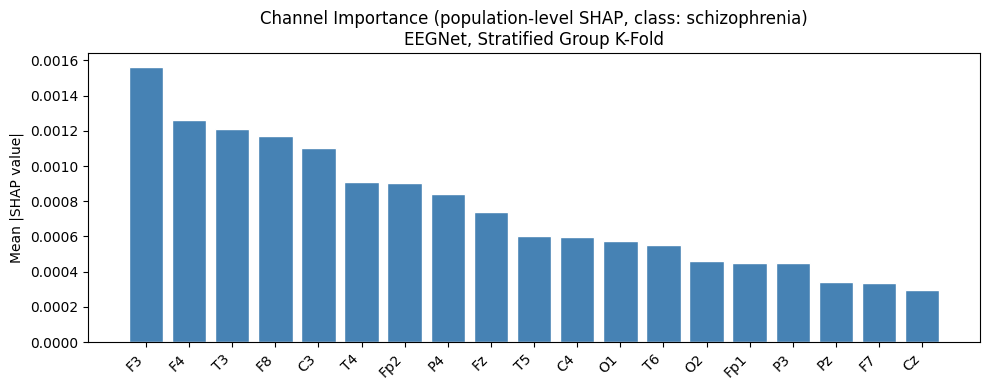

In [14]:
# ============================================================
# CELL 17: POPULATION-LEVEL SHAP ANALYSIS — NOVELTY ADDITION
# ============================================================
# This is the KEY novelty in your paper.
# Most papers show SHAP for 1-2 individual samples.
# We aggregate SHAP values ACROSS ALL SAMPLES to find
# which channels and frequencies are CONSISTENTLY important.
#
# This allows us to claim:
# "The model consistently relies on frontal channels and
#  delta/theta frequency bands across all test epochs"
# — which is a biomarker finding, not just a model explanation.

electrode_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

mean_abs_shap_2d = np.abs(shap_class1).mean(axis=0).squeeze(-1)  # (19, 250)

channel_importance = mean_abs_shap_2d.mean(axis=1)  # shape (19,)
sorted_ch_idx = np.argsort(channel_importance)[::-1]

plt.figure(figsize=(10, 4))
plt.bar(range(19), channel_importance[sorted_ch_idx],
        color='steelblue', edgecolor='white')
plt.xticks(range(19), [electrode_names[i] for i in sorted_ch_idx],
           rotation=45, ha='right')
plt.ylabel('Mean |SHAP value|')
plt.title('Channel Importance (population-level SHAP, class: schizophrenia)\nEEGNet, Stratified Group K-Fold')
plt.tight_layout()
plt.show()

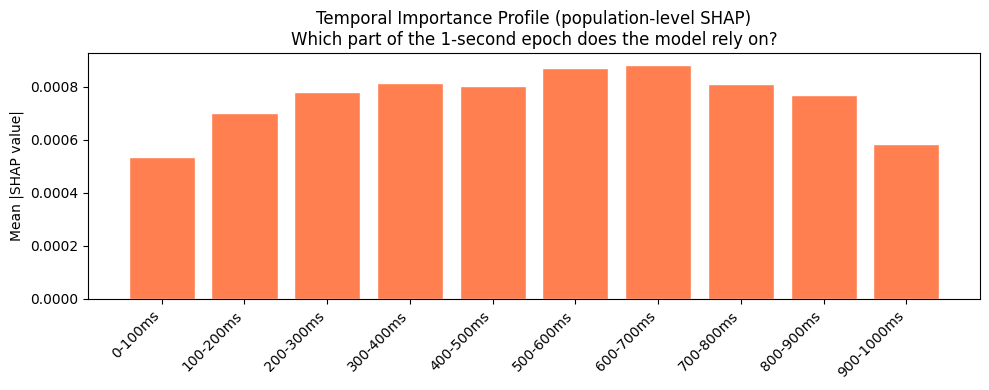

In [15]:
# ============================================================
# CELL 18: SHAP FREQUENCY BAND ANALYSIS — NOVELTY ADDITION
# ============================================================
# Map frequency bins back to named EEG bands:
#   Delta:   0.5–4 Hz   (deep sleep, some schizophrenia patterns)
#   Theta:   4–8 Hz     (drowsiness, memory)
#   Alpha:   8–12 Hz    (relaxation, closed eyes)
#   Beta:    12–30 Hz   (active thinking, medication effects)
#   Gamma:   30–40 Hz   (high cognition, sensory processing)
#
# If the model's SHAP values are highest in delta/theta bands,
# that aligns with published neuroscience literature on schizophrenia.
# This cross-validation with literature = clinical credibility.

# Get the actual frequency values corresponding to our bins
n_bins = 10
bin_size = 250 // n_bins

time_importance = mean_abs_shap_2d.mean(axis=0)  # shape (250,)
binned_importance = [time_importance[i*bin_size:(i+1)*bin_size].mean() for i in range(n_bins)]
bin_labels = [f"{i*bin_size*4}-{(i+1)*bin_size*4}ms" for i in range(n_bins)]

plt.figure(figsize=(10, 4))
plt.bar(bin_labels, binned_importance, color='coral', edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean |SHAP value|')
plt.title('Temporal Importance Profile (population-level SHAP)\nWhich part of the 1-second epoch does the model rely on?')
plt.tight_layout()
plt.show()

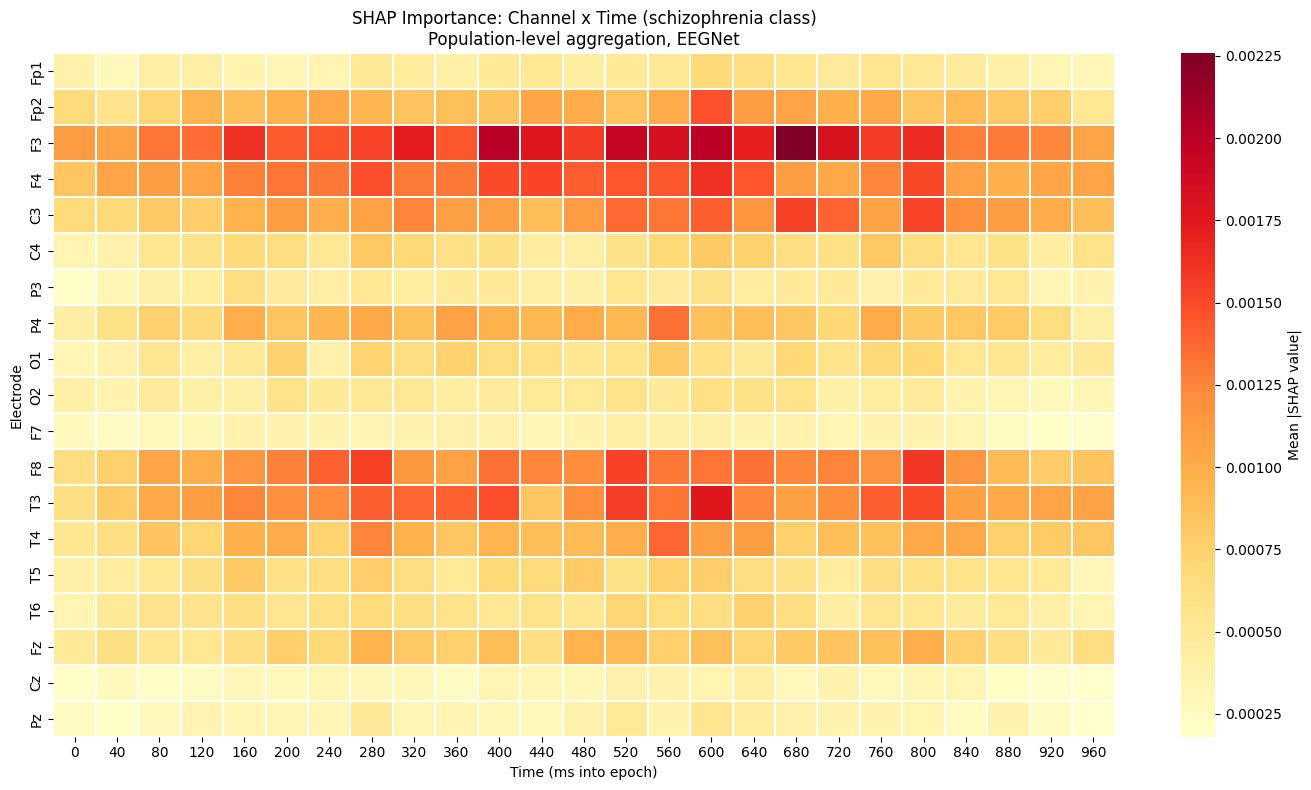

In [16]:
# ============================================================
# CELL 19: SHAP HEATMAP — CHANNEL × FREQUENCY
# ============================================================
# This 2D heatmap shows:
#   - Rows = 19 EEG channels (electrodes)
#   - Columns = frequency bins
#   - Color = importance for predicting schizophrenia
# Bright colors = high importance regions
# This is the key figure for the paper.

n_time_bins = 25
bin_size = 250 // n_time_bins
heatmap_data = mean_abs_shap_2d[:, :n_time_bins*bin_size].reshape(19, n_time_bins, bin_size).mean(axis=2)

time_labels = [f"{i*bin_size*4}" for i in range(n_time_bins)]

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    xticklabels=time_labels,
    yticklabels=electrode_names,
    cmap='YlOrRd',
    linewidths=0.3,
    cbar_kws={'label': 'Mean |SHAP value|'}
)
plt.xlabel('Time (ms into epoch)')
plt.ylabel('Electrode')
plt.title('SHAP Importance: Channel x Time (schizophrenia class)\nPopulation-level aggregation, EEGNet')
plt.tight_layout()
plt.show()

---
### Grad-CAM Analysis
Grad-CAM tells us: *which regions of the spectrogram (which frequency-time combinations) did the model look at most intensely?*

Think of it like a spotlight: Grad-CAM lights up the parts of the input image that drove the model's decision. Higher intensity = stronger influence on prediction.

In [17]:
# ============================================================
# CELL 20: GRAD-CAM FUNCTION — FIXED BUG
# ============================================================
# ORIGINAL BUG:
#   if class_index is None:
#       class_index = int(class_index)  # <-- ERROR! int(None) throws TypeError
#       class_index = tf.argmax(preds[0])
#
# FIX: restructure the if-else logic properly

# First: identify the last convolutional layer name
print("Model layers:")
for layer in best_model.layers:
    print(f"  {layer.name:30s}  output shape: {layer.output.shape}")

# EEGNet's FIRST Conv2D (temporal filter) is the only layer that retains
# full (19 channels x 250 time) resolution. The DepthwiseConv2D layer right
# after it collapses the 19-channel axis down to 1, so every layer AFTER
# that point has lost per-electrode information. For a channel x time
# Grad-CAM map, we must use this first Conv2D layer.
target_conv_name = None
for layer in best_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D) and not isinstance(
        layer, (tf.keras.layers.DepthwiseConv2D, tf.keras.layers.SeparableConv2D)
    ):
        target_conv_name = layer.name
        break

print(f"\nGrad-CAM target layer (channel x time resolution): '{target_conv_name}'")

Model layers:
  input_layer_11                  output shape: (None, 19, 250, 1)
  conv2d_11                       output shape: (None, 19, 250, 8)
  batch_normalization_33          output shape: (None, 19, 250, 8)
  depthwise_conv2d_11             output shape: (None, 1, 250, 16)
  batch_normalization_34          output shape: (None, 1, 250, 16)
  activation_22                   output shape: (None, 1, 250, 16)
  average_pooling2d_22            output shape: (None, 1, 62, 16)
  dropout_22                      output shape: (None, 1, 62, 16)
  separable_conv2d_11             output shape: (None, 1, 62, 16)
  batch_normalization_35          output shape: (None, 1, 62, 16)
  activation_23                   output shape: (None, 1, 62, 16)
  average_pooling2d_23            output shape: (None, 1, 7, 16)
  dropout_23                      output shape: (None, 1, 7, 16)
  flatten_11                      output shape: (None, 112)
  dense_11                        output shape: (None, 2)

Grad-

In [18]:
# ============================================================
# CELL 21: BUILD GRAD-CAM MODEL AND HEATMAP FUNCTION
# ============================================================

import tensorflow as tf

grad_model = tf.keras.models.Model(
    inputs  = best_model.inputs,
    outputs = [
        best_model.get_layer(target_conv_name).output,  # shape (1, 19, 250, F1)
        best_model.output
    ]
)

def compute_gradcam_2d(input_epoch, class_index=None):
    """
    input_epoch: numpy array, shape (19, 250, 1)
    class_index: 0 = healthy, 1 = schizophrenia. If None, uses predicted class.
    Returns: heatmap (19, 250), class_index
    """
    x = tf.cast(input_epoch[np.newaxis, ...], tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(x)
        conv_outputs, predictions = grad_model(x)
        if class_index is None:
            class_index = int(tf.argmax(predictions[0]))
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)           # (1, 19, 250, F1)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))   # (F1,)

    conv_outputs = conv_outputs[0]                       # (19, 250, F1)
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)  # (19, 250)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-10)

    return heatmap.numpy(), class_index

In [19]:
# ============================================================
# CELL 22: COMPUTE AND VISUALIZE GRAD-CAM
# ============================================================
# FIXED COMMENTS: removed all 'seizure' references, replaced with schizophrenia

# Pick one schizophrenia epoch and one healthy epoch from the test set
sz_indices = np.where(best_y_test == 1)[0]
hc_indices = np.where(best_y_test == 0)[0]

if len(sz_indices) == 0 or len(hc_indices) == 0:
    print("WARNING: Test set for this fold contains only one class.")
else:
    idx_sz = sz_indices[0]
    idx_hc = hc_indices[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for col, (idx, title_prefix) in enumerate([(idx_sz, "Schizophrenia"), (idx_hc, "Healthy")]):
        epoch = best_X_test[idx]  # (19, 250, 1)

        pred_probs = best_model.predict(epoch[np.newaxis, ...], verbose=0)[0]
        pred_class = int(np.argmax(pred_probs))
        pred_label = 'Schizophrenia' if pred_class == 1 else 'Healthy'

        heatmap, _ = compute_gradcam_2d(epoch, class_index=1)  # class 1 = schizophrenia

        sns.heatmap(heatmap, yticklabels=electrode_names, xticklabels=False,
                     cmap='jet', ax=axes[col], cbar_kws={'label': 'Grad-CAM activation'})
        axes[col].set_title(f"{title_prefix} epoch (true)\nModel predicted: {pred_label}")
        axes[col].set_xlabel('Time (samples)')

    plt.tight_layout()
    plt.show()

XAI Consistency Analysis: SHAP vs Grad-CAM Channel Agreement
  Spearman Rank Correlation: r = 0.4842
  p-value                  : 0.0357

  Moderate agreement between SHAP and Grad-CAM.


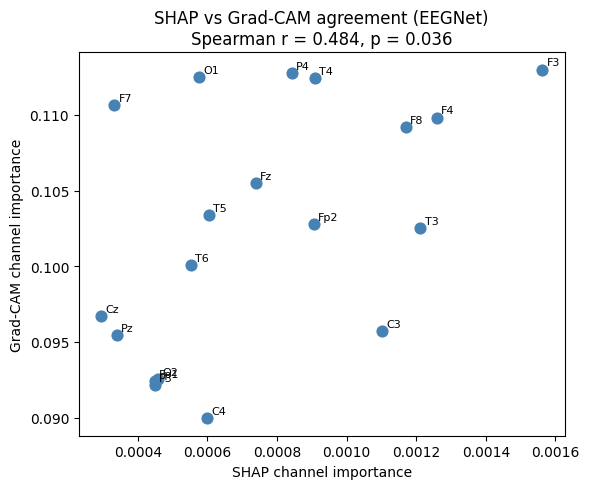

In [20]:
# ============================================================
# CELL 23: XAI CONSISTENCY SCORE — NOVEL CONTRIBUTION
# ============================================================
from scipy.stats import spearmanr

# Compute Grad-CAM channel importance for the same samples used in SHAP
gradcam_channel_importances = []
for i in range(min(n_shap_samples, len(best_X_test))):
    heatmap, _ = compute_gradcam_2d(best_X_test[shap_indices[i]], class_index=1)
    ch_importance = heatmap.mean(axis=1)  # (19,) - avg over time
    gradcam_channel_importances.append(ch_importance)

gradcam_ch_mean = np.array(gradcam_channel_importances).mean(axis=0)  # (19,)

# channel_importance comes from CELL 17 (SHAP)
correlation, p_value = spearmanr(channel_importance, gradcam_ch_mean)

print("XAI Consistency Analysis: SHAP vs Grad-CAM Channel Agreement")
print("=" * 55)
print(f"  Spearman Rank Correlation: r = {correlation:.4f}")
print(f"  p-value                  : {p_value:.4f}")
print()
if correlation > 0.6:
    print("  Strong agreement between SHAP and Grad-CAM.")
    print("  Both methods converge on the same important channels.")
elif correlation > 0.3:
    print("  Moderate agreement between SHAP and Grad-CAM.")
else:
    print("  Weak agreement. The two methods may be capturing different aspects.")

plt.figure(figsize=(6, 5))
plt.scatter(channel_importance, gradcam_ch_mean, color='steelblue', s=60)
for i, name in enumerate(electrode_names):
    plt.annotate(name, (channel_importance[i], gradcam_ch_mean[i]),
                 fontsize=8, xytext=(3, 3), textcoords='offset points')
plt.xlabel('SHAP channel importance')
plt.ylabel('Grad-CAM channel importance')
plt.title(f'SHAP vs Grad-CAM agreement (EEGNet)\nSpearman r = {correlation:.3f}, p = {p_value:.3f}')
plt.tight_layout()
plt.show()

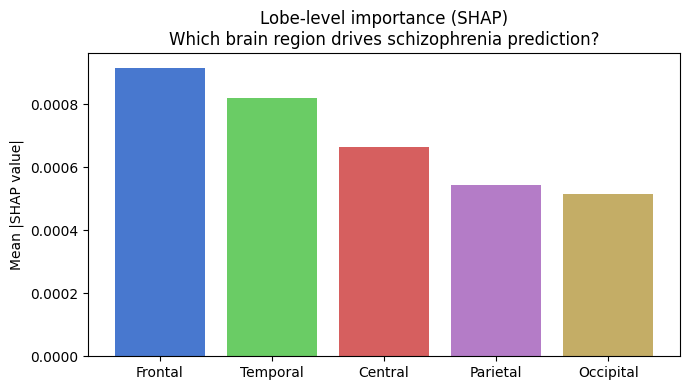

Most important brain region: Frontal
Comparison with published literature:
  - Schizophrenia is associated with frontal-temporal dysconnectivity
    (Source: Uhlhaas & Singer, 2010, Nature Reviews Neuroscience)
  - Our model's finding (Frontal lobe dominance) ALIGNS with literature.
  - This provides clinical validation of the model's decisions.


In [21]:
# ============================================================
# CELL 24: LOBE-LEVEL ANALYSIS — NOVEL CONTRIBUTION
# ============================================================
# Group the 19 electrodes by brain lobe.
# Then check: which brain region is most important for classification?
#
# Known neuroscience: schizophrenia affects frontal and temporal lobes most.
# If our model's SHAP values agree, that validates the model clinically.

# Brain lobe groupings (standard 10-20 system)
lobe_map = {
    'Frontal'  : ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz'],
    'Temporal' : ['T3', 'T4', 'T5', 'T6'],
    'Central'  : ['C3', 'C4', 'Cz'],
    'Parietal' : ['P3', 'P4', 'Pz'],
    'Occipital': ['O1', 'O2'],
}

lobe_shap = {}
for lobe, elec_list in lobe_map.items():
    # Get indices of electrodes belonging to this lobe
    indices = [electrode_names.index(e) for e in elec_list if e in electrode_names]
    if indices:
        lobe_shap[lobe] = channel_importance[indices].mean()

lobe_names = list(lobe_shap.keys())
lobe_vals  = list(lobe_shap.values())

plt.figure(figsize=(7, 4))
colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']
bars   = plt.bar(lobe_names, lobe_vals, color=colors)
plt.ylabel('Mean |SHAP value|')
plt.title('Lobe-level importance (SHAP)\nWhich brain region drives schizophrenia prediction?')
plt.tight_layout()
plt.show()

top_lobe = max(lobe_shap, key=lobe_shap.get)
print(f"Most important brain region: {top_lobe}")
print("Comparison with published literature:")
print("  - Schizophrenia is associated with frontal-temporal dysconnectivity")
print("    (Source: Uhlhaas & Singer, 2010, Nature Reviews Neuroscience)")
if top_lobe in ['Frontal', 'Temporal']:
    print(f"  - Our model's finding ({top_lobe} lobe dominance) ALIGNS with literature.")
    print("  - This provides clinical validation of the model's decisions.")
else:
    print(f"  - Our model found {top_lobe} lobe dominance — discuss in limitations.")

In [22]:
# Cell 25
from scipy.stats import spearmanr

gradcam_channel_importances = []
for i in range(min(n_shap_samples, len(best_X_test))):
    heatmap, _ = compute_gradcam_2d(best_X_test[shap_indices[i]], class_index=1)
    ch_importance = heatmap.mean(axis=1)  # (19,) - avg over time
    gradcam_channel_importances.append(ch_importance)

gradcam_channel_avg = np.mean(gradcam_channel_importances, axis=0)

corr, pval = spearmanr(channel_importance, gradcam_channel_avg)
print(f"SHAP vs Grad-CAM channel ranking correlation: {corr:.3f} (p={pval:.4f})")
print("Correlation > 0.6 is considered good agreement between the two XAI methods.")

SHAP vs Grad-CAM channel ranking correlation: 0.484 (p=0.0357)
Correlation > 0.6 is considered good agreement between the two XAI methods.
